In [1]:


import os
import sys
import subprocess

# Cài certifi nếu máy chưa có
try:
    import certifi
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "certifi"])
    import certifi

# Lấy đường dẫn certificate đúng của certifi
cert_path = certifi.where()

# Ép Python/requests dùng certificate đúng
os.environ["REQUESTS_CA_BUNDLE"] = cert_path
os.environ["SSL_CERT_FILE"] = cert_path

print("Đã set SSL certificate thành:")
print(cert_path)

print("\nKiểm tra biến môi trường hiện tại:")
print("REQUESTS_CA_BUNDLE =", os.environ.get("REQUESTS_CA_BUNDLE"))

print("SSL_CERT_FILE =", os.environ.get("SSL_CERT_FILE"))

Đã set SSL certificate thành:
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\certifi\cacert.pem

Kiểm tra biến môi trường hiện tại:
REQUESTS_CA_BUNDLE = c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\certifi\cacert.pem
SSL_CERT_FILE = c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\certifi\cacert.pem


In [2]:
import sys

!{sys.executable} -m pip install -U vnstock_data

ERROR: Could not find a version that satisfies the requirement vnstock_data (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for vnstock_data


In [3]:
pip install -U vnstock

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip show vnstock

Name: vnstock
Version: 4.0.2
Summary: A beginner-friendly yet powerful Python toolkit for financial analysis and automation — built to make modern investing accessible to everyone
Home-page: 
Author: 
Author-email: Thinh Vu <support@vnstocks.com>
License: Custom: Personal, research, non-commercial; contact support@vnstocks.com for other use
Location: C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: beautifulsoup4, importlib-metadata, openpyxl, packaging, pandas, psutil, pydantic, pytz, requests, seaborn, tenacity, vnai, vnstock_ezchart
Required-by: vnstock_ezchart


In [23]:
from vnstock import Vnstock
from vnstock import Quote
from vnstock import Listing
from vnstock import Finance
from vnstock import Company
import matplotlib 
import matplotlib.pyplot as plt
import time
import pandas as pd
listing = Listing(source='VCI')

In [6]:
industry_df = listing.symbols_by_industries()

industry_df

,symbol,organ_name,com_type_code,icb_level,icb_code,icb_name
0,A32,Công ty Cổ phần 32,CT,1,3000,Hàng Tiêu dùng
1,A32,Công ty Cổ phần 32,CT,2,3700,Hàng cá nhân & Gia dụng
2,A32,Công ty Cổ phần 32,CT,3,3760,Hàng cá nhân
3,A32,Công ty Cổ phần 32,CT,4,3765,Giầy dép
4,AAA,Công ty Cổ phần Nhựa An Phát Xanh,CT,1,1000,Nguyên vật liệu
...,...,...,...,...,...,...
7691,YEG,Công ty Cổ phần Tập đoàn Yeah1,CT,4,5553,Giải trí & Truyền thông
7692,YTC,Công ty Cổ phần Xuất nhập khẩu Y tế Thành phố ...,CT,1,4000,Dược phẩm và Y tế
7693,YTC,Công ty Cổ phần Xuất nhập khẩu Y tế Thành phố ...,CT,2,4500,Y tế
7694,YTC,Công ty Cổ phần Xuất nhập khẩu Y tế Thành phố ...,CT,3,4530,Thiết bị và Dịch vụ Y tế


In [7]:
target_industry = "Điện, nước & xăng dầu khí đốt"

filtered_df = industry_df[
    industry_df["icb_name"].astype(str).str.contains(
        target_industry,
        case=False,
        na=False,
        regex=False
    )
].copy()

filtered_df

,symbol,organ_name,com_type_code,icb_level,icb_code,icb_name
277,ASP,Công ty Cổ phần Tập đoàn Dầu khí An Pha,CT,2,7500,"Điện, nước & xăng dầu khí đốt"
313,AVC,Công ty Cổ phần Thủy điện A Vương,CT,2,7500,"Điện, nước & xăng dầu khí đốt"
429,BDW,Công ty Cổ phần Cấp thoát nước Bình Định,CT,2,7500,"Điện, nước & xăng dầu khí đốt"
445,BGE,Công ty Cổ phần BCG Energy,CT,2,7500,"Điện, nước & xăng dầu khí đốt"
457,BGW,Công ty Cổ phần Nước sạch Bắc Giang,CT,2,7500,"Điện, nước & xăng dầu khí đốt"
...,...,...,...,...,...,...
7405,VPW,Công ty Cổ phần Cấp thoát nước số 1 Vĩnh Phúc,CT,2,7500,"Điện, nước & xăng dầu khí đốt"
7449,VSH,Công ty Cổ phần Thủy điện Vĩnh Sơn - Sông Hinh,CT,2,7500,"Điện, nước & xăng dầu khí đốt"
7585,VWS,Công ty Cổ phần Nước và Môi trường Việt Nam,CT,2,7500,"Điện, nước & xăng dầu khí đốt"
7613,WTB,Công ty Cổ Phần Thuỷ Điện To Buông,CT,2,7500,"Điện, nước & xăng dầu khí đốt"


In [8]:
for i in filtered_df["symbol"].unique():
    print(i)

ASP
AVC
BDW
BGE
BGW
BHA
BLW
BMF
BNW
BSA
BTP
BTW
BWA
BWE
BWS
CCI
CGC
CHP
CHS
CLW
CMW
CNG
CTW
CVH
DBW
DDG
DKW
DLM
DMS
DNA
DNC
DNH
DNN
DNW
DRL
DTE
DTK
DTV
DVC
DWC
DWS
EAD
GAS
GCB
GDW
GE2
GEG
GHC
GLW
GSM
HDW
HFC
HGW
HIO
HJS
HNA
HND
HPD
HPW
HTC
HTW
HWS
ISH
KHP
KHW
KTW
KWA
LAW
LCW
LDW
LKW
LWS
MTG
NAW
NBP
NBT
NBW
ND2
NDW
NLS
NNT
NQB
NQN
NQT
NS2
NS3
NSL
NT2
NTH
NTW
NVP
PBK
PCG
PDT
PEG
PGC
PGD
PGS
PGV
PIC
PJC
PJS
PMG
PMW
PND
POB
POV
POW
PPC
PPT
PPY
PSH
PTH
PTX
PVG
PWS
QNW
QPH
QTP
REE
S4A
SBA
SBH
SEB
SFC
SHP
SII
SJD
SMA
SP2
STW
SVH
TAW
TBC
TBW
TDB
TDG
TDM
TDW
THN
THW
TLP
TMC
TMP
TNW
TOW
TQW
TTA
TTE
TVW
UIC
UPC
VAV
VCP
VCW
VLW
VMG
VPD
VPW
VSH
VWS
WTB
XMP


In [9]:
finance = Finance(symbol="ASP", source= "KBS")
bcdkt = finance.balance_sheet(period= "year")
bcdkt.head()

,item,item_id,2025-Năm,2024-Năm,2023-Năm,2022-Năm
0,TÀI SẢN,assets,NaN,NaN,NaN,NaN
1,A. TÀI SẢN NGẮN HẠN,a.short_term_assets,673070424.0,809260745.0,1.309627e+09,1.097024e+09
2,I. Tiền và các khoản tương đương tiền,i.cash_and_cash_equivalents,76813856.0,189235486.0,2.159892e+08,1.227334e+08
3,1. Tiền,n_1.cash,76813856.0,129235486.0,2.159892e+08,8.631725e+07
4,2. Các khoản tương đương tiền,n_2.cash_equivalents,NaN,60000000.0,NaN,3.641620e+07


In [10]:
ts = bcdkt.loc[
    bcdkt["item"].isin(["A. TÀI SẢN NGẮN HẠN", "B. TÀI SẢN DÀI HẠN"]),
    '2025-Năm'
].sum()

print(ts)

1327198991.0


In [11]:
results = []
skipped = []

In [12]:
symbols = filtered_df["symbol"].dropna().unique()

for i in symbols:
    try:
        finance = Finance(symbol=i, source="KBS")
        bcdkt = finance.balance_sheet(period="year")
        if "2025-Năm" not in bcdkt.columns:
            print(i, "Không có BCTC 2025")
            skipped.append(i)
            continue

        ts = bcdkt.loc[
            bcdkt["item"].isin(["A. TÀI SẢN NGẮN HẠN", "B. TÀI SẢN DÀI HẠN"]),
            "2025-Năm"
        ].sum()
        # Bỏ qua nếu không có dữ liệu tài sản
        if pd.isna(ts) or ts == 0:
            print(i, "Không có dữ liệu tài sản 2025")
            skipped.append(i)
            continue

        results.append({
            "symbol": i,
            "total_assets_2025": ts
        })

        print(i, ts) 

        time.sleep(1.2)

    except SystemExit:
        print("Đụng rate limit, chờ 20 giây rồi chạy tiếp...")
        time.sleep(20)
        continue

    except Exception as e:
        print(f"Lỗi mã {i}: {e}")
        skipped.append({"symbol": i, "reason": str(e)})
        time.sleep(1.2)



ASP 1327198991.0
AVC 1341897534.0
BDW 458199640.0
BGE Không có BCTC 2025
BGW 243006548.0
BHA 1464983910.0
BLW Không có BCTC 2025
BMF 643997969.0
BNW 928816308.0
BSA 1247828985.0
BTP 1218678652.0
BTW 384095302.0
BWA 110436991.0
BWE 15148255852.0
BWS 1240958007.0
CCI 1093993676.0
CGC Không có BCTC 2025
CHP 2616813677.0

⚠️ 
⚠️  GIỚI HẠN API ĐÃ ĐẠT TỐI ĐA (Rate Limit Exceeded)

📌 Bạn đã đạt giới hạn tối đa số lượt yêu cầu API trong 1 phút (minute).
   (You have reached the maximum API request limit for this period)

📊 Chi tiết (Details):
   • Gói hiện tại: Khách (Guest)
   • Giới hạn: 20 requests/phút
   • Đã sử dụng: 20/20
   • Chờ 50 giây để tiếp tục (Wait to retry)

💡 Giải pháp (Solutions):
   1️⃣ Chờ 50 giây rồi thử lại
      (Wait and retry)
   2️⃣ Tham gia chương trình tài trợ dự án (Sponsor) để sử dụng không gián đoạn.
      Lưu ý: vnstock là công cụ mã nguồn mở giúp tự động hoá kết nối với
      các API công khai mà bạn vốn đã có quyền truy cập hợp lệ, không
      phải nhà cung cấ

In [13]:
assets_df = pd.DataFrame(results)
assets_df = (
    assets_df
    .sort_values("total_assets_2025", ascending=False)
    .drop_duplicates(subset="symbol", keep="first")
    .reset_index(drop=True)
)

top15 = assets_df.head(15)

top15

,symbol,total_assets_2025
0,GAS,9.356820e+10
1,PGV,5.503180e+10
2,REE,4.007485e+10
3,DTK,1.533704e+10
4,BWE,1.514826e+10
5,GEG,1.511089e+10
6,PSH,1.050614e+10
7,TLP,9.485990e+09
8,NT2,9.273311e+09
9,VSH,8.171337e+09


In [14]:
# Danh sách 15 doanh nghiệp có vốn hóa lớn nhất ngành
top15_list = pd.merge(top15,filtered_df[['symbol', 'organ_name', 'icb_name']], on = 'symbol', how = 'left')
top15_list

,symbol,total_assets_2025,organ_name,icb_name
0,GAS,9.356820e+10,Tổng Công ty Khí Việt Nam - Công ty Cổ phần,"Điện, nước & xăng dầu khí đốt"
1,PGV,5.503180e+10,Tổng Công ty Phát điện 3 - Công ty Cổ phần,"Điện, nước & xăng dầu khí đốt"
2,REE,4.007485e+10,Công ty Cổ phần Cơ điện Lạnh,"Điện, nước & xăng dầu khí đốt"
3,DTK,1.533704e+10,Tổng Công ty Điện lực TKV - Công ty Cổ phần,"Điện, nước & xăng dầu khí đốt"
4,BWE,1.514826e+10,Công ty Cổ phần - Tổng công ty Nước - Môi trườ...,"Điện, nước & xăng dầu khí đốt"
5,GEG,1.511089e+10,Công ty Cổ phần Điện Gia Lai,"Điện, nước & xăng dầu khí đốt"
6,PSH,1.050614e+10,Công ty Cổ phần Thương mại Đầu tư Dầu khí Nam ...,"Điện, nước & xăng dầu khí đốt"
7,TLP,9.485990e+09,Tổng Công ty Thương mại Xuất nhập khẩu Thanh L...,"Điện, nước & xăng dầu khí đốt"
8,NT2,9.273311e+09,Công ty Cổ phần Điện lực Dầu khí Nhơn Trạch 2,"Điện, nước & xăng dầu khí đốt"
9,VSH,8.171337e+09,Công ty Cổ phần Thủy điện Vĩnh Sơn - Sông Hinh,"Điện, nước & xăng dầu khí đốt"


In [15]:
company = Company(symbol='VCP', source='KBS')
company.ownership()

,owner_type,ownership_percentage,shares_owned,update_date
0,CĐ lớn,59.5,49860900,2024-12-31T00:00:00
1,CĐ khác,40.5,33928758,2024-12-31T00:00:00


In [17]:
# Cổ đông lớn nhất
ownership_results = []

for n in top15_list["symbol"].dropna().astype(str).str.strip().str.upper().drop_duplicates():
    try:
        company = Company(symbol= n, source='KBS')
        own = company.ownership()

        top_holder = (
            own.dropna(subset = ["ownership_percentage"])
            .sort_values("ownership_percentage", ascending = False)
            .head(1))
        row = top_holder.iloc[0]

        ownership_results.append({
            "symbol": n,
            "owner_type": row["owner_type"],
            "ownership_percentage": row["ownership_percentage"],
            "shares_owned": row["shares_owned"],
            "update_date": row["update_date"]
        })
    except Exception as e:
        print(f"Lỗi {n}: {e}")

ownership_df = pd.DataFrame(ownership_results)

ownership_df


,symbol,owner_type,ownership_percentage,shares_owned,update_date
0,GAS,CĐ Nhà nước,95.76,2310692875,2025-12-31T00:00:00
1,PGV,CĐ Nhà nước,99.19,1114422994,2025-12-31T00:00:00
2,REE,Tổ chức nước ngoài,48.70,263766016,2026-02-27T00:00:00
3,DTK,CĐ Nhà nước,99.27,677808500,2025-12-31T00:00:00
4,BWE,Tổ chức trong nước,74.14,163055097,2025-12-31T00:00:00
5,GEG,CĐ trong nước,63.35,226995254,2025-12-31T00:00:00
6,PSH,CĐ trong nước khác,56.71,71563680,2024-12-31T00:00:00
7,TLP,Cá nhân trong nước,62.50,147884500,2024-12-31T00:00:00
8,NT2,Tổ chức trong nước,73.43,211397896,2025-12-31T00:00:00
9,VSH,Tổ chức trong nước,57.76,136441367,2025-12-31T00:00:00


In [ ]:
List_portfolio = pd.merge(top15_list, ownership_df[['symbol', 'owner_type', 'ownership_percentage']], on = "symbol", how = "left")
List_portfolio

,symbol,total_assets_2025,organ_name,icb_name,owner_type,ownership_percentage
0,POW,8.861193e+10,Tổng Công ty Điện lực Dầu khí Việt Nam - CTCP,"Điện, nước & xăng dầu khí đốt",CĐ Nhà nước,79.94
1,PGV,5.503180e+10,Tổng Công ty Phát điện 3 - Công ty Cổ phần,"Điện, nước & xăng dầu khí đốt",CĐ Nhà nước,99.19
2,REE,4.007485e+10,Công ty Cổ phần Cơ điện Lạnh,"Điện, nước & xăng dầu khí đốt",Tổ chức nước ngoài,48.70
3,DTK,1.533704e+10,Tổng Công ty Điện lực TKV - Công ty Cổ phần,"Điện, nước & xăng dầu khí đốt",CĐ Nhà nước,99.27
4,BWE,1.514826e+10,Công ty Cổ phần - Tổng công ty Nước - Môi trườ...,"Điện, nước & xăng dầu khí đốt",Tổ chức trong nước,74.14
5,GEG,1.511089e+10,Công ty Cổ phần Điện Gia Lai,"Điện, nước & xăng dầu khí đốt",CĐ trong nước,63.35
6,PSH,1.050614e+10,Công ty Cổ phần Thương mại Đầu tư Dầu khí Nam ...,"Điện, nước & xăng dầu khí đốt",CĐ trong nước khác,56.71
7,TLP,9.485990e+09,Tổng Công ty Thương mại Xuất nhập khẩu Thanh L...,"Điện, nước & xăng dầu khí đốt",Cá nhân trong nước,62.50
8,VSH,8.171337e+09,Công ty Cổ phần Thủy điện Vĩnh Sơn - Sông Hinh,"Điện, nước & xăng dầu khí đốt",Tổ chức trong nước,57.76
9,QTP,7.775427e+09,Công ty Cổ phần Nhiệt điện Quảng Ninh,"Điện, nước & xăng dầu khí đốt",Tổ chức trong nước,89.16


GAS

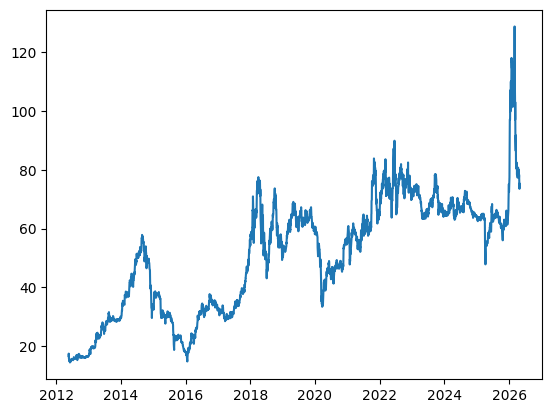

In [25]:
quote = Quote(symbol='GAS', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


POW	

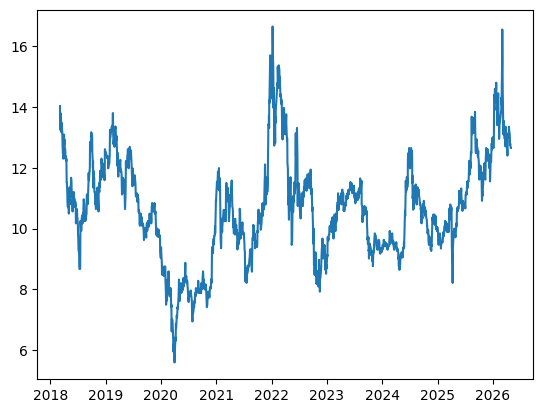

In [26]:
quote = Quote(symbol='POW', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


PGV

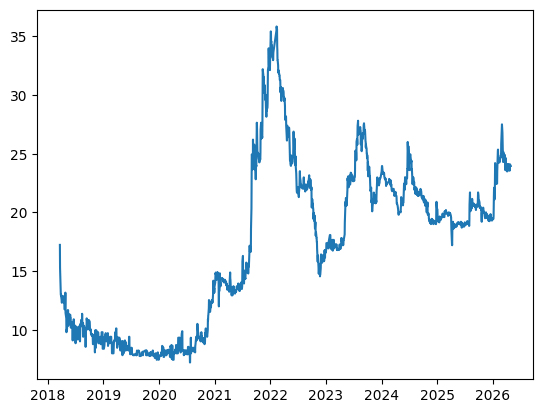

In [27]:
quote = Quote(symbol='PGV', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


REE

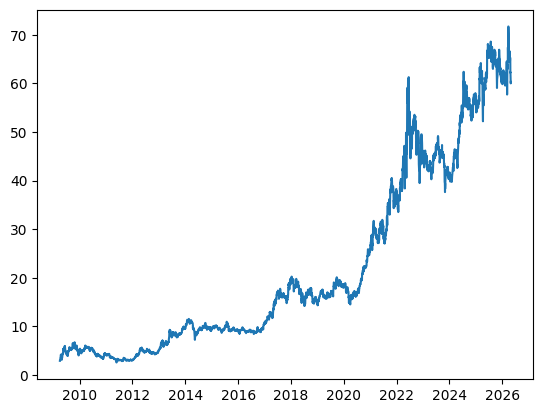

In [28]:
quote = Quote(symbol='REE', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


DTK	

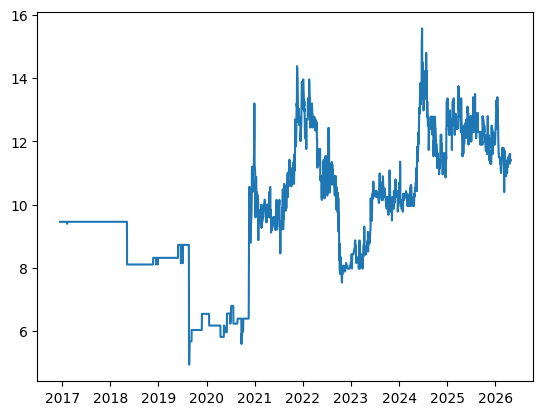

In [29]:
quote = Quote(symbol='DTK', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


BWE

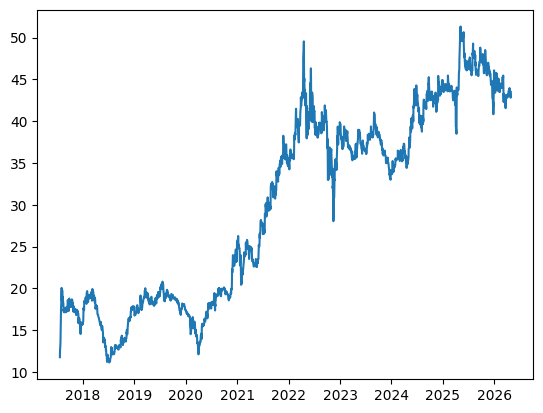

In [30]:
quote = Quote(symbol='BWE', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


GEG	

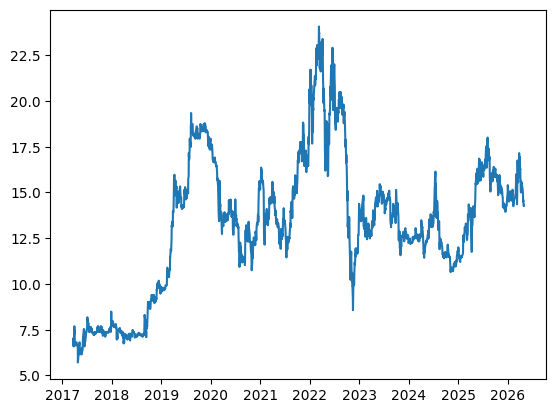

In [31]:
quote = Quote(symbol='GEG', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


PSH	

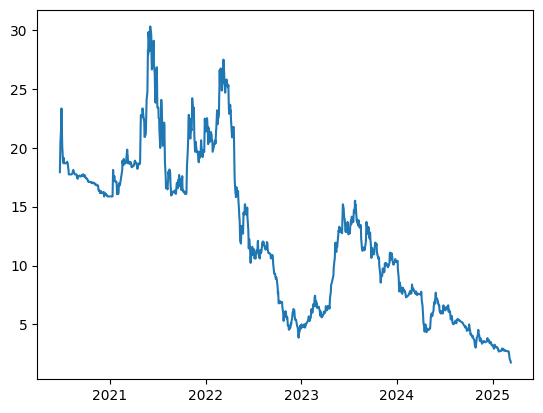

In [32]:
quote = Quote(symbol='PSH', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


TLP

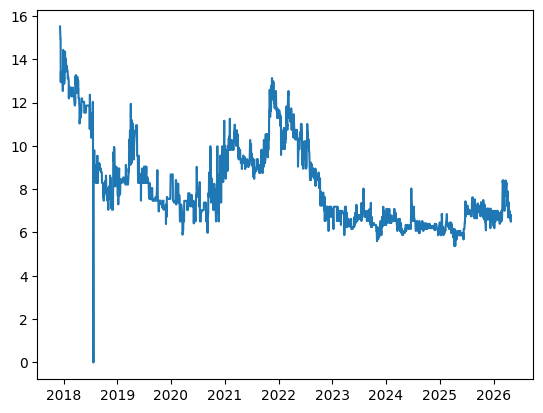

In [33]:
quote = Quote(symbol='TLP', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


NT2

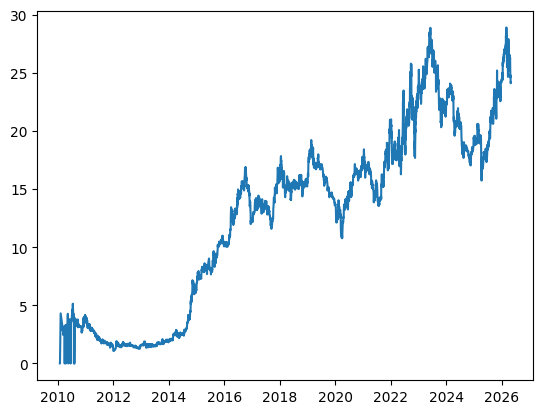

In [34]:
quote = Quote(symbol='NT2', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


VSH

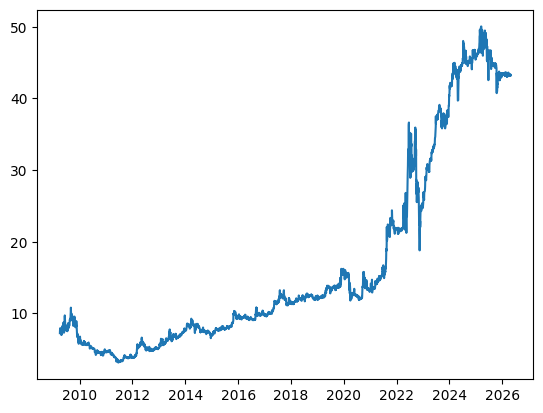

In [35]:
quote = Quote(symbol='VSH', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


QTP	

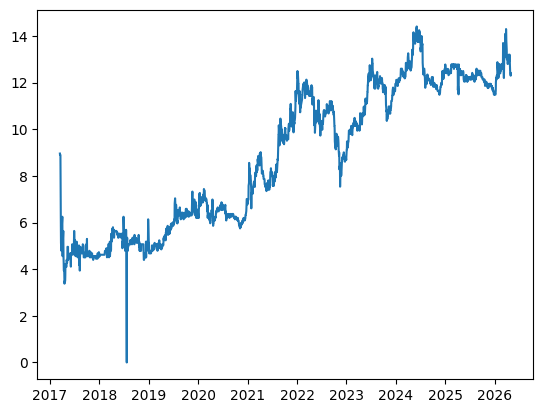

In [36]:
quote = Quote(symbol='QTP', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


DNH

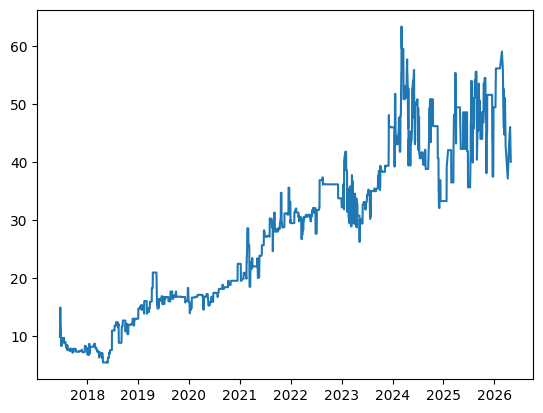

In [37]:
quote = Quote(symbol='DNH', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


HND

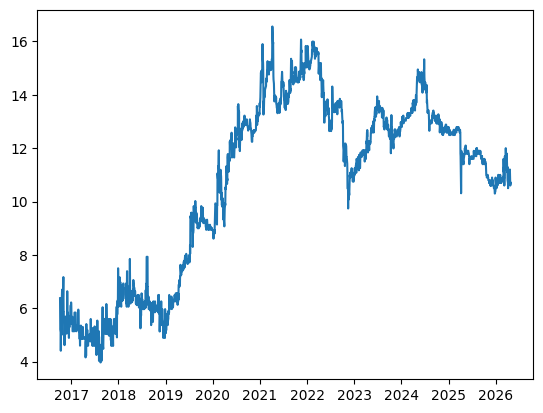

In [38]:
quote = Quote(symbol='HND', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])


VCP	

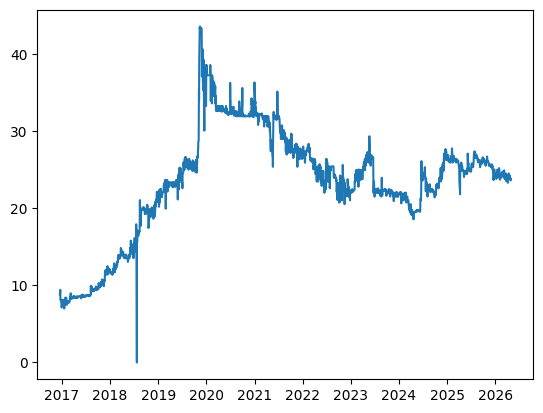

In [39]:
quote = Quote(symbol='VCP', source='VCI')
gas = quote.history(start='2010-01-01', end='2026-05-02', interval="1D")
plt.plot(gas['time'], gas['close'])
